In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state==self.goal
        # Return True if state is equal to the goal state.

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions=[]
        row,col=state
        for action in MOVES:
            dr, dc = MOVES[action]
            Row = row + dr
            Col = col + dc
            neighbour = (Row,Col)
            if self.in_bounds(neighbour):
              if self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc =MOVES[action]
        Row= row+dr
        Col=col+dc
        return (Row , Col)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        s =node.state
        for action in problem.actions(s):
          s_prime= problem.result(s, action)
          cost= node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


In [ ]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        row,col=next_state

        # Steps:
        # 1. Unpack next_state into row and col.
        return self.terrain_costs[row][col]


In [ ]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    r1,c1 =state
    r2,c2=goal
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    return math.dist(state,goal)
    # Hint: math.sqrt(...) or math.dist(state, goal).


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0


In [ ]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")


Heuristic self-check passed.


In [ ]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0



In [ ]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        startingnode=Node(problem.initial_state())
        frontier=PriorityQueue()
        inode=self.evaluation(startingnode, problem)
        frontier.push(inode,startingnode)
        reached={startingnode.state:startingnode}
        nodes_expanded=0
        max_frontier_size=1
        while len(frontier)>0:
          m=frontier.pop()
          if problem.is_goal(m.state):
            success=SearchResult(algorithm=self.algorithm_name,status="success",solution=m, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))
            return success
          nodes_expanded=nodes_expanded+1
          for child in self.expand(problem,m):
            s=child.state
            if s not in reached or child.path_cost<reached[s].path_cost:
              reached[s]=child
              frontier.push(self.evaluation(child,problem),child)
            if len(frontier)>max_frontier_size:
              max_frontier_size=len(frontier)


        failure=SearchResult(algorithm=self.algorithm_name,status="failure",solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))
        return failure
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.


In [ ]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        return self.h(node, problem)
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).


In [ ]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        return node.path_cost + self.h(node, problem)
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.


In [ ]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [ ]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        return node.path_cost + (self.weight * self.h(node,problem))
        # Weighted A*: f(n) = g(n) + W * h(n).


In [ ]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)



,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


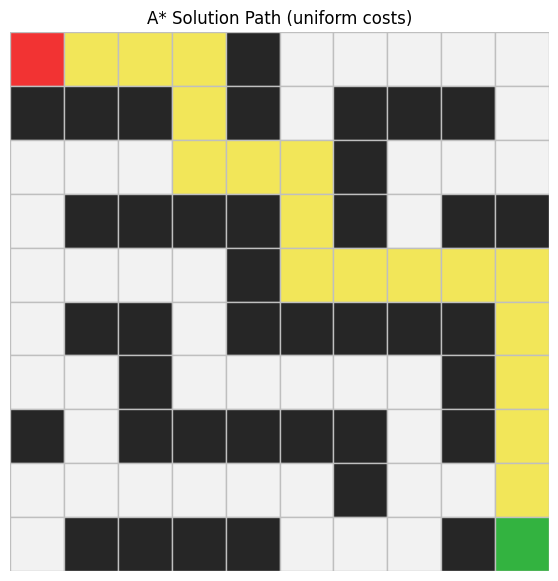

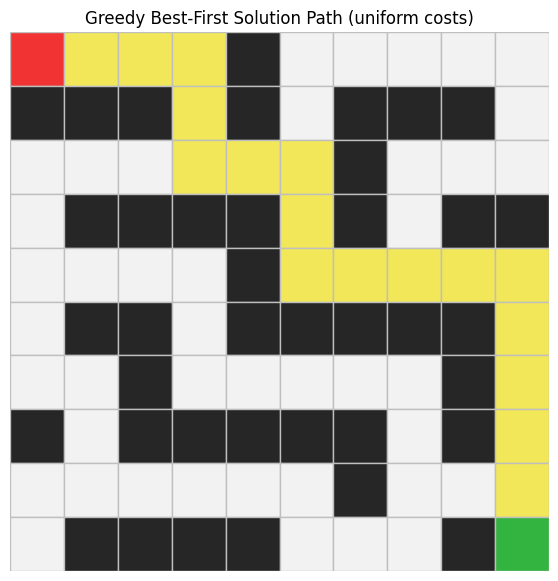

In [ ]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)


In [ ]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


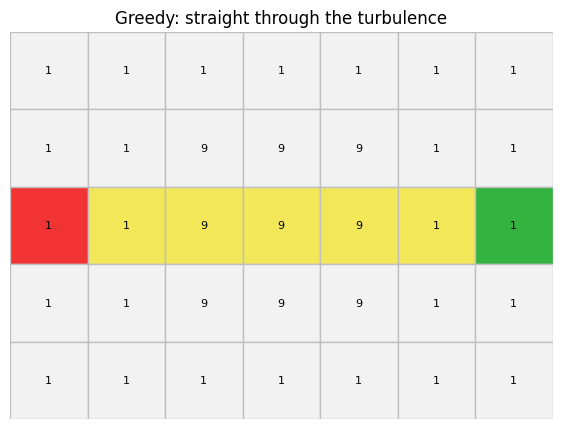

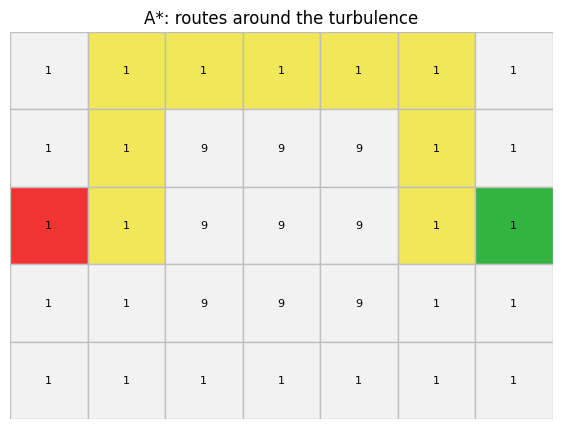

In [ ]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)


In [ ]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    def h(state,goal):
      return factor*manhattan_distance(state,goal)
    return h
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


In [ ]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid
    [0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,],
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,],
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,],
    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,],

]

custom_costs_1 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [8, 1, 1, 7, 2, 5, 1, 1, 8, 1, 1, 7, 2, 5, 1],
    [2, 1, 45, 60, 1, 100, 90, 20, 8, 1, 1, 7, 2, 5, 1],
    [10, 20,30, 1, 1,90, 80, 1, 8, 1, 1, 7, 2, 5, 1],
    [19, 1, 15, 27, 22, 33, 1, 44, 8, 1, 1, 7, 2, 5, 1],
    [1, 88, 15, 55, 34, 20, 7, 1, 8, 1, 1, 7, 2, 5, 1],
    [1, 18, 15, 1, 12, 11, 1, 9, 8, 1, 1, 7, 2, 5, 1],
    [1, 18, 15, 1, 12, 11, 1, 9, 8, 1, 1, 7, 2, 5, 1],
    [1, 18, 15, 1, 12, 11, 1, 9, 8, 1, 1, 7, 2, 5, 1],
    [8, 1, 1, 7, 2, 5, 1, 1, 8, 1, 1, 7, 2, 5, 1],
    [2, 1, 45, 60, 1, 100, 90, 20, 8, 1, 1, 7, 2, 5, 1],
    [10, 20,30, 1, 1,90, 80, 1, 8, 1, 1, 7, 2, 5, 1],
    [19, 1, 15, 27, 22, 33, 1, 44, 8, 1, 1, 7, 2, 5, 1],
    [1, 88, 15, 55, 34, 20, 7, 1, 8, 1, 1, 7, 2, 5, 1],
    [1, 18, 15, 1, 12, 11, 1, 9, 8, 1, 1, 7, 2, 5, 1],
    [1, 18, 15, 1, 12, 11, 1, 9, 8, 1, 1, 7, 2, 5, 1],
]

custom_start_1 = (0,1)
custom_goal_1 = (5,9)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
     ucs.search(custom_problem_1),
     astar.search(custom_problem_1),
     wastar2.search(custom_problem_1),
     greedy.search(custom_problem_1),
 ]
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,53,419,99,9,105
1,A*,success,53,419,98,9,105
2,Weighted A* (W=2),success,53,419,98,7,105
3,Greedy,success,51,522,147,17,90


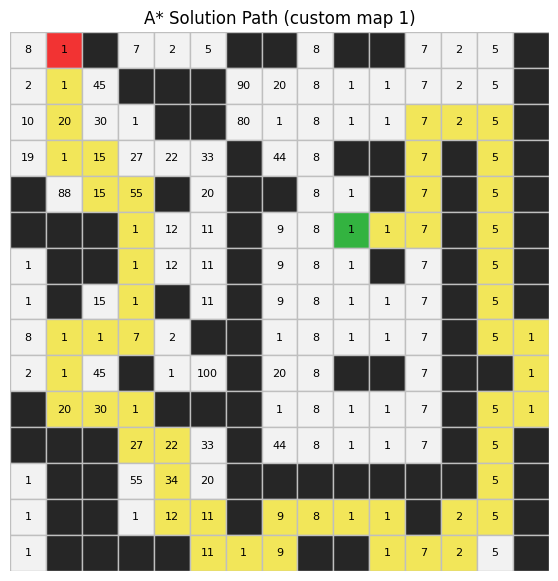

In [ ]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* Solution Path (custom map 1)",
)

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [

    # Replace this with your own grid.
    # Replace this with your own grid
    [0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,],
    [1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,],
    [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,],
    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,],
]
#custom_costs_2 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
#]
custom_start_2 = (0,2)
custom_goal_2 = (5,7)

# Example after completing:
custom_problem_2 = GridProblem(
     custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     ucs.search(custom_problem_2),
     astar.search(custom_problem_2),
     wastar2.search(custom_problem_2),
     greedy.search(custom_problem_2),]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,52,52,120,9,125
1,A*,success,52,52,97,14,110
2,Weighted A* (W=2),success,52,52,92,12,100
3,Greedy,success,52,52,92,12,100


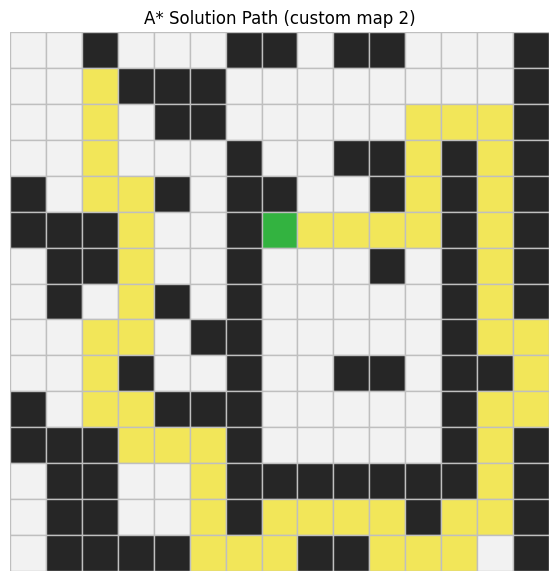

In [ ]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="A* Solution Path (custom map 2)",
)

# 16.1 Heuristic Functions

1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?

h(n) estimates the cost still left to reach the goal from a node. Its knowledge comes from the GPS of the node and the goal.


2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

It removes obstacles and terrain costs. Manhattan pretends every cell is free and each step costs 1, so the drone can move straight to the goal without walls or expensive cells blocking it.


3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

It removes obstacles and terrain costs. Manhattan pretends every cell is free and each step costs 1, so the drone can move straight to the goal without walls or expensive cells blocking it.


4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

With costs of at least 1, each step costs at least as much as Manhattan counts, so Manhattan never overestimates and stays admissible. With a cost of 0.5, a real path could be cheaper than the step count, so Manhattan would overestimate, become inadmissible, and break optimality.



# 16.2 Greedy Best-First Search


1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?


Greedy ignores g(n), the cost already travelled. The turbulence map punished it by making it rush toward the goal through costly turbulent cells, giving an expensive path.


2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?


Fewer nodes only means it ran faster, not that it found a better path. Greedy is not optimal, so it can still return a worse, more costly route.


3. Describe a drone mission where Greedy's behaviour would actually be acceptable.



A mission where you just need a quick route fast and the path cost barely matters, like an emergency over open, flat terrain with no expensive cells.


# 16.3 A* Search

1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan?


f(n) is the total estimated cost of the flight plan: the cost already flown from the start to the current cell plus the estimated cost still to go to the goal.



2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?

When a node is popped, A* has confirmed the cheapest path to it. If it tested the goal when generated, it could accept the goal through a costly path before a cheaper one is found. On the turbulence map an early goal test could return an expensive route instead of the optimal one.


3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?


Because terrain costs vary, the same state can be reached again by a cheaper path, so reached must store the best node per state and update it. A plain set only records that a state was seen and cannot compare costs. BFS in Part A had equal step costs, so the first time a state was reached was always best.


4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?



A* expands fewer nodes than UCS because the heuristic guides it toward the goal. The size of the gap shows the value of the heuristic: it cuts out wasted exploration.


# 16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?

Admissible means h(n) never overestimates the true cost to the goal. Consistent means h(n) is less than or equal to the step cost plus the next node's heuristic. Consistency implies admissibility.


2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

It showed that with an inadmissible heuristic A* loses its optimality guarantee and can return a non-optimal path. So the optimality claim only holds when the heuristic is admissible.


3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.

Yes. One move costs 1, and Manhattan changes by exactly 1 per move, so h(n) is at most c(n, a, n') plus h(n'). The triangle inequality holds, so Manhattan is consistent.



# 16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A*, and Greedy?


 The weight sets f(n) = g(n) + W times h(n). W of 0 gives UCS (only g), W of 1 gives normal A*, and a large W pushes it toward Greedy (h takes over). So W slides between UCS, A*, and Greedy.


2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?

It guarantees the solution cost is at most W times the optimal cost. Yes, the experiments stayed well inside that bound.

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

Weighted A* with a moderate W like 1.5. A higher W expands fewer nodes so it plans faster on the slow computer, and the W times optimal bound keeps the path cheap enough to stay inside the 90 seconds of battery margin.



# 16.6 Memory and Real-World Drone Context

1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?


2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?


3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?


4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?